# **Universidad Austral**
# **Facultad de Ingenieria**
# Inteligenca Artificial para Datos Biomedicos

### Clase 4 - Práctica: Transformers - Finetuning

En esta clase, vamos a explorar cómo utilizar los modelos Transformers para la clasificación de notas clínicas. Vamos a descargar un modelo preentrenado basado en la arquitectura Transformer y lo vamos a fine-tunear para clasificar evolución clínica de pacientes


**DOCENTES​**

Paulo Veiga

Marco Sanchez Sorondo


**Octubre 2024**

Carga de la librerias
- Solo la primera vez, debemos instalarlas (si estamos en Google Colab debemos hacerlo cada vez que iniciemos sesion)

In [ ]:
# Instalacion de librerias
!pip install openai
!pip install evaluate==0.4.3
!pip install -U huggingface_hub
!pip install -U transformers datasets evaluate
!pip install -U sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.5 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting unin

In [ ]:
import os
from IPython.display import Image

import pandas as pd
import numpy as np

# Carga de librerias
import torch
print('torch version: ',torch.__version__)
from torch.optim import AdamW
import torch.nn.functional as F

import transformers
print('transformers version: ',transformers.__version__)
from transformers import BertTokenizer, BertModel, BertForSequenceClassification, AutoTokenizer, AutoModel
from transformers import TrainingArguments, EarlyStoppingCallback, Trainer, TrainerCallback
from datasets import Dataset

import evaluate
import subprocess

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, matthews_corrcoef
from sklearn.manifold import TSNE
import numpy as np

from sentence_transformers import SentenceTransformer

import openai

import warnings
warnings.filterwarnings('ignore')

torch version:  2.10.0+cu128
transformers version:  5.3.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set the folder as the default working directory
default_dir = '/content/drive/MyDrive/austral_centralizado/IA para Ingeniería Biomédica/Clase 4: Fine-Tuning, Metricas y Calidad de Datos/'
os.chdir(default_dir)

# Verify the current working directory
print("Current working directory:", os.getcwd())

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/austral_centralizado/IA para Ingeniería Biomédica/Clase 4: Fine-Tuning, Metricas y Calidad de Datos


Chequeamos si tenemos disponible GPU

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


# Run the nvidia-smi command and capture its output
result = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# Check if the command was successful
if result.returncode == 0:
    # Print the output of nvidia-smi
    print("nvidia-smi output:")
    print(result.stdout)
else:
    # Print any error messages if the command failed
    print("nvidia-smi command failed with error:")
    print(result.stderr)

cuda
nvidia-smi output:
Wed Mar 25 16:31:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------

## Introducción a BERT

BERT (Bidirectional Encoder Representations from Transformers) es un modelo de lenguaje desarrollado por Google que ha revolucionado el procesamiento del lenguaje natural (NLP). A diferencia de los modelos de lenguaje anteriores, BERT utiliza una arquitectura basada en transformers que le permite entender el contexto de una palabra en una oración considerando tanto las palabras anteriores como las posteriores. Esto le otorga una capacidad superior para comprender el significado de frases complejas y realizar tareas como la clasificación de texto.

La arquitectura de BERT consta de múltiples componentes interconectados, incluyendo capas de atención y embeddings, que trabajan en conjunto para procesar las entradas. Cada componente del modelo desempeña un papel crucial en la forma en que BERT transforma los tokens de entrada en representaciones semánticas ricas y contextuales.


## Carguemos nuestro primer modelo

En el ámbito biomédico, BERT ha sido aplicado exitosamente a tareas como clasificación de notas clínicas, extracción de información de historias clínicas y análisis de sentimiento en textos médicos.

In [ ]:
# Cargar el modelo y el tokenizador
model_name = 'google-bert/bert-base-multilingual-uncased'  # modelo BERT BASE, sin distinguir entre mayusculas y minusculas y multilenguaje
model = BertForSequenceClassification.from_pretrained(model_name)

tokenizer = BertTokenizer.from_pretrained(model_name)
print(f'cargado el tokenizer de {model_name}')
vocab_size = tokenizer.vocab_size
print(f'Tokenizer Vocabulary Size: {vocab_size}')


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

cargado el tokenizer de google-bert/bert-base-multilingual-uncased
Tokenizer Vocabulary Size: 105879


#### Contexto del Warning
El warning indica que al inicializar un modelo de clasificación de secuencias (`BertForSequenceClassification`) a partir del checkpoint del modelo `google-bert/bert-base-multilingual-uncased`, algunos de los pesos no se han cargado desde el checkpoint y han sido inicializados de nuevo.

#### Detalles del Warning

#### Pesos no inicializados
Los pesos mencionados (`classifier.bias` y `classifier.weight`) son específicos de la capa de clasificación del modelo. Esto significa que el modelo está diseñado para hacer predicciones en una tarea específica (como clasificación de texto) y necesita esos pesos para hacerlo.

#### Causas
- **Checkpoint Incompatible**: El modelo preentrenado no incluye la capa de clasificación. Al cargar un modelo de preentrenamiento en una arquitectura que espera una capa de clasificación (como `BertForSequenceClassification`), los pesos de esa capa deben ser inicializados desde cero.
  
- **Tarea Específica**: Este warning es común cuando se utiliza un modelo preentrenado para un propósito diferente al que fue entrenado originalmente (por ejemplo, usar un modelo de lenguaje general para clasificación).

#### Recomendación
El warning sugiere que deberías **entrenar el modelo** en tu tarea específica (por ejemplo, clasificación de texto) para ajustar esos pesos recién inicializados. Sin entrenamiento adicional, el modelo no tendrá el conocimiento necesario para hacer predicciones precisas en tu conjunto de datos.


## Exploremos como funciona

In [ ]:
# Oración de ejemplo
sentence = "El paciente presenta buena evolución postoperatoria y signos vitales estables. Se planifica alta médica"

# Tokenizar la oración
inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True)

# Obtener los IDs de los tokens
token_ids = inputs['input_ids']

# Convertir los IDs de vuelta a tokens
tokens = tokenizer.convert_ids_to_tokens(token_ids[0])

# Mostrar los tokens y sus IDs
for token, token_id in zip(tokens, token_ids[0]):
    print(f"Token: {token}")

Token: [CLS]
Token: el
Token: paciente
Token: presenta
Token: buena
Token: evolucion
Token: posto
Token: ##pera
Token: ##toria
Token: y
Token: sign
Token: ##os
Token: vitale
Token: ##s
Token: estable
Token: ##s
Token: .
Token: se
Token: plan
Token: ##ifica
Token: alta
Token: medica
Token: [SEP]


In [ ]:
# Ejemplos de distintos tipos de tokens
# 1. Token regular: una palabra que está completamente en el vocabulario de BERT.
word_token = "fiebre"
word_token_ids = tokenizer(word_token)['input_ids']
word_token_decoded = tokenizer.convert_ids_to_tokens(word_token_ids[1:-1])  # Excluye [CLS] y [SEP]

# 2. Token subpalabra: una palabra que se descompone en subpalabras.
subword_token = "electrocardiograma"
subword_token_ids = tokenizer(subword_token)['input_ids']
subword_token_decoded = tokenizer.convert_ids_to_tokens(subword_token_ids[1:-1])

# 3. Token especial: por ejemplo, [CLS] y [SEP] que se añaden automáticamente en el tokenizador de BERT.
sentence = "El paciente presenta disnea"
special_tokens = tokenizer(sentence)['input_ids']
special_token_decoded = tokenizer.convert_ids_to_tokens(special_tokens)  # Incluye todos los tokens

# Mostrar ejemplos
print(f"Token regular: {word_token_decoded}, IDs: {word_token_ids[1:-1]}")
print(f"Token subpalabra: {subword_token_decoded}, IDs: {subword_token_ids[1:-1]}")
print(f"Tokens especiales: {special_token_decoded}, IDs: {special_tokens}")

Token regular: ['fie', '##bre'], IDs: [29031, 16043]
Token subpalabra: ['electro', '##card', '##io', '##grama'], IDs: [51900, 48484, 10625, 56782]
Tokens especiales: ['[CLS]', 'el', 'paciente', 'presenta', 'dis', '##nea', '[SEP]'], IDs: [101, 10117, 72496, 15552, 23145, 24760, 102]


Realicemos un ejercicio para ver las diferencias entre los tokenizers de los diversos modelos.

Al analizar cómo cada uno de ellos segmenta y representa el texto, podemos obtener una visión más clara de las particularidades y enfoques únicos que ofrecen. Esta comparación nos permitirá apreciar cómo cada tokenizer adapta su funcionamiento a las características específicas de su modelo, lo que puede influir significativamente en la calidad del procesamiento del lenguaje y en la comprensión contextual de las palabras.


In [ ]:
tokenizer_bert_base_uncased = BertTokenizer.from_pretrained('bert-base-uncased')
print(f'tokenizer_bert_base_uncased - Vocabulary Size: {tokenizer_bert_base_uncased.vocab_size}')
tokenizer_bert_base_multilingual_uncased = BertTokenizer.from_pretrained('google-bert/bert-base-multilingual-uncased')
print(f'tokenizer_bert_base_multilingual_uncased - Vocabulary Size: {tokenizer_bert_base_multilingual_uncased.vocab_size}')
tokenizer_bert_base_spanish_uncased = BertTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased')
print(f'tokenizer_bert_base_spanish_uncased - Vocabulary Size: {tokenizer_bert_base_spanish_uncased.vocab_size}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_bert_base_uncased - Vocabulary Size: 30522
tokenizer_bert_base_multilingual_uncased - Vocabulary Size: 105879


tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

tokenizer_bert_base_spanish_uncased - Vocabulary Size: 31002


In [ ]:
# Definir la función para tokenizar
def tokenize_sentence(tokenizer, sentence):
    # Tokenizar la oración
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True)

    # Obtener los IDs de los tokens
    token_ids = inputs['input_ids']

    # Convertir los IDs de vuelta a tokens
    tokens = tokenizer.convert_ids_to_tokens(token_ids[0])

    # Mostrar los tokens en una sola línea
    print(" | ".join(tokens))

# Ejemplo de oración
sentence = "El paciente presenta buena evolución postoperatoria y signos vitales estables. Se planifica alta médica"

# Probar con diferentes tokenizers
tokenizers = {
    "bert_base_uncased": tokenizer_bert_base_uncased,
    "bert_base_multilingual_uncased": tokenizer_bert_base_multilingual_uncased,
    "bert_base_spanish_uncased": tokenizer_bert_base_spanish_uncased,
}

# Aplicar la función a cada tokenizer
for name, tokenizer in tokenizers.items():
    print(f"\nTokenizing with {name}:")
    tokenize_sentence(tokenizer, sentence)


Tokenizing with bert_base_uncased:
[CLS] | el | pac | ##iente | present | ##a | buena | ev | ##ol | ##uc | ##ion | post | ##oper | ##ator | ##ia | y | sign | ##os | vital | ##es | est | ##able | ##s | . | se | plan | ##ific | ##a | alta | med | ##ica | [SEP]

Tokenizing with bert_base_multilingual_uncased:
[CLS] | el | paciente | presenta | buena | evolucion | posto | ##pera | ##toria | y | sign | ##os | vitale | ##s | estable | ##s | . | se | plan | ##ifica | alta | medica | [SEP]

Tokenizing with bert_base_spanish_uncased:
[CLS] | el | paciente | presenta | buena | evolución | post | ##op | ##erato | ##ria | y | signos | vitales | estables | . | se | planific | ##a | alta | médica | [SEP]


A medida que exploramos diferentes modelos de tokenización, se hace evidente que aquellos diseñados para ser más específicos y contextualizados logran representar mejor las palabras del lenguaje, incluyendo terminología médica.

Por ejemplo, el modelo BERT base español, al estar entrenado con datos en español, capta matices y sutilezas del idioma, incluyendo terminología clínica, que podrían pasar desapercibidos para modelos más generales.

Esto se traduce en una representación más rica y precisa de los tokens, reflejando no solo el significado literal de las palabras, sino también su contexto y uso dentro de frases específicas.

Esta capacidad de adaptación a diferentes lenguajes y contextos resalta la importancia de utilizar modelos especializados para tareas de procesamiento del lenguaje natural, mejorando así la eficacia y la calidad de los resultados obtenidos.

---

# Contextual Word Embeddings

Las embeddings contextuales son representaciones de palabras que capturan el significado de una palabra en función de su contexto en una oración. A diferencia de las embeddings tradicionales, como Word2Vec, que generan una única representación para cada palabra, las embeddings contextuales varían según el entorno en el que la palabra aparece. Para ilustrar este concepto, vamos a trabajar con BERT (Bidirectional Encoder Representations from Transformers), un modelo de lenguaje que genera embeddings altamente contextuales, permitiendo capturar matices semánticos específicos de cada palabra en una oración.

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = BertModel.from_pretrained('bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
text = "The patient was discharged from the ward after the doctor discharged his duties." # "discharge" tiene significado diferente: dar de alta vs cumplir funciones

In [ ]:
inputs = tokenizer(text, return_tensors='pt', add_special_tokens=True)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

inputs = tokenizer(text, return_tensors='pt')
with torch.no_grad():
    outputs = model_bert(**inputs)

# Extract the last hidden state (embeddings for each token)
embeddings = outputs.last_hidden_state

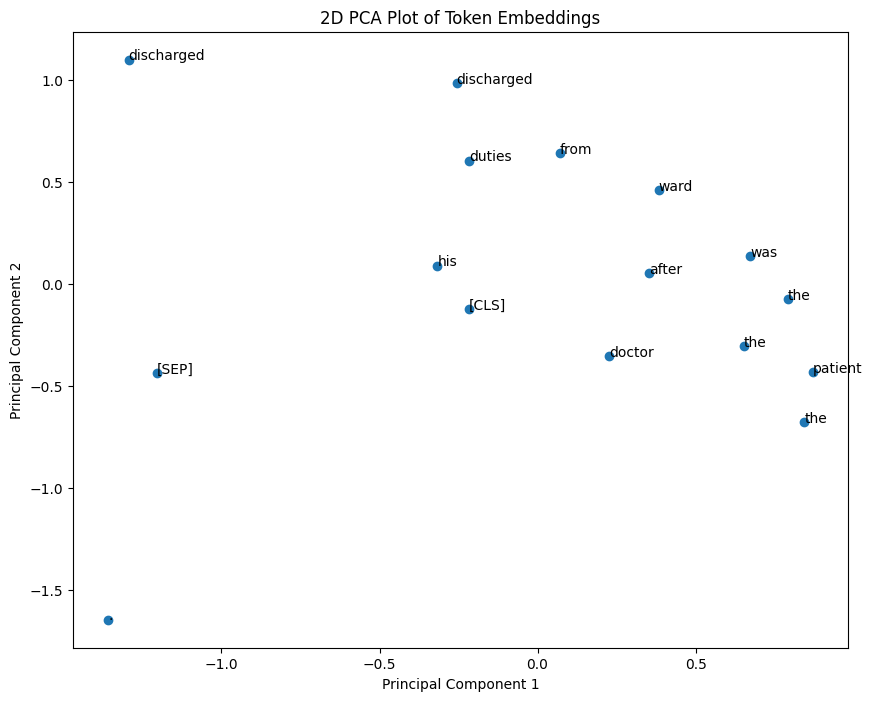

In [ ]:
token_embeddings = []
for embedding in embeddings[0]:
    first_five_values = embedding[:20].numpy()
    token_embeddings.append(first_five_values)

# Convert list of embeddings to a numpy array
token_embeddings = np.array(token_embeddings)

# Apply PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(token_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

# Annotate each point with the corresponding token
for i, token in enumerate(tokens):
    plt.annotate(token, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.title('2D PCA Plot of Token Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

A simple podemos observar que cada palabra (token) tiene su propio embedding diferenciado.

De hecho vemos que baseball funciona como separador de ambos bat.

# Sentence Embeddings (Los embeddings en Clasificación)

Sentence embeddings son representaciones numéricas de oraciones que capturan su significado semántico en un espacio de alta dimensión. A diferencia de las representaciones tradicionales de palabras, como word embeddings, que asignan un vector a cada palabra individual, los sentence embeddings encapsulan el significado completo de una oración o frase, permitiendo que los modelos de procesamiento de lenguaje natural comprendan mejor el contexto y las relaciones entre oraciones. Estas representaciones son fundamentales para tareas como la comparación de oraciones, la búsqueda semántica, y la inferencia textual, facilitando un entendimiento más profundo del lenguaje a nivel de oración.

## Pooling Average

Average pooling es una técnica utilizada en redes neuronales, especialmente en el procesamiento de lenguaje natural, para reducir la dimensionalidad de las representaciones vectoriales y capturar información global. En el contexto de sentence embeddings, se refiere al proceso de calcular el promedio de los vectores de palabras que componen una oración. Al promediar los vectores, se obtiene una representación única que resume el contenido semántico de toda la oración, equilibrando la influencia de cada palabra. Este método es simple pero efectivo, ya que suaviza las variaciones locales y resalta el significado general de la oración, lo que lo convierte en una opción popular para generar sentence embeddings en modelos de lenguaje



## Token CLS
En BERT y modelos basados en Transformers, se introduce un token especial `[CLS]` (“classification”) al inicio de cada secuencia de entrada. Durante el preentrenamiento, el vector correspondiente a este token aprende a capturar una representación global de la oración completa. Para generar un embedding de frase mediante esta técnica, basta con extraer el embedding de salida del token `[CLS]` en la última capa:


## Sentence Bert
Sentence-BERT (SBERT) es una extensión de BERT diseñada específicamente para generar sentence embeddings de alta calidad, optimizados para medir similitud y realizar clustering o recuperación de oraciones. SBERT introduce dos innovaciones clave:

Veamos cómo difieren los embeddings producidos por Average Pooling, Token CLS y Sentence‑BERT en la práctica. Usaremos dos oraciones y compararemos sus similitudes de coseno.


In [ ]:
list_sentences = [
    # --- discharge polysemy ---
    "The patient was discharged from the hospital after a full recovery.",
    "The wound showed a purulent discharge that required immediate attention.",
    "The electrical discharge from the defibrillator restored normal heart rhythm.",
    "After being discharged, the patient followed up with outpatient physical therapy.",
    # --- culture polysemy ---
    "The blood culture confirmed the presence of Staphylococcus aureus.",
    "The hospital culture emphasizes patient-centered care and safety.",
    "A positive blood culture was obtained before starting empiric antibiotics.",
    # --- positive polysemy ---
    "The patient had a positive outcome after the cardiac surgery.",
    "The rapid test came back positive for influenza A.",
    "A positive culture result changed the antibiotic regimen.",
    # --- monitor polysemy ---
    "The nurse continued to monitor the patient's vital signs every hour.",
    "The cardiac monitor displayed a normal sinus rhythm throughout the night.",
    "We need to closely monitor renal function given the nephrotoxic medication.",
    # --- clinical paraphrases ---
    "The patient's condition improved significantly after surgery.",
    "Post-surgical recovery was excellent with marked clinical improvement.",
    "Vital signs remained stable: BP 120/80, HR 72, SpO2 98%.",
    "Blood pressure, heart rate, and oxygen saturation were all within normal limits.",
    # --- astronomy control group ---
    "The telescope captured a clear image of Saturn's rings last night.",
    "Astronauts train in neutral-buoyancy pools to simulate weightlessness.",
    "A solar flare disrupted radio signals across the hemisphere.",
    # --- mixed context ---
    "The discharge summary noted that the wound culture was positive for MRSA.",
    "The monitor showed an irregular rhythm as the patient was being discharged.",
    "Hospital culture promotes early discharge when patients show positive evolution.",
    "The nurse used the bedside monitor to track vitals before the patient's discharge.",
    "A positive blood culture led to extended monitoring in the intensive care unit.",
    "The patient completed her rehabilitation ahead of schedule and was discharged early.",
    "Early discharge planning improved patient satisfaction scores across the ward.",
]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

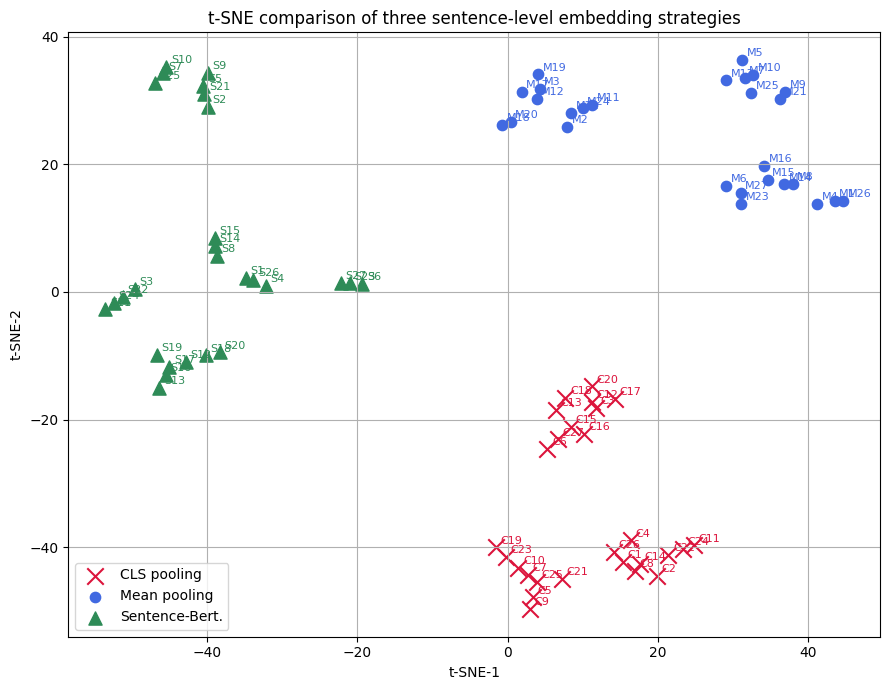

In [ ]:
# --- models ---------------------------------------------------------------

bert_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(bert_name)
model_bert = AutoModel.from_pretrained(bert_name)

sent_model_name = "all-mpnet-base-v2"       # 768-dim, matches BERT
sent_model = SentenceTransformer(sent_model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device).eval()
sent_model.to(device).eval()


# --- collect embeddings ---------------------------------------------------
cls_emb, avg_emb, sent_emb = [], [], []

with torch.no_grad():
    for sent in list_sentences:
        # Tokenise for BERT
        inpt = tokenizer(sent, return_tensors='pt',
                         truncation=True, max_length=512).to(device)

        out = model_bert(**inpt).last_hidden_state      # [1, L, 768]

        # ① CLS pooling  -----------------------------
        cls_emb.append(out[:, 0, :].squeeze().cpu().numpy())

        # ② Mean pooling -----------------------------
        #   (mask-aware: ignore [PAD] tokens)
        attn_mask = inpt["attention_mask"]
        mean_vec = (out * attn_mask.unsqueeze(-1)).sum(1) / attn_mask.sum(1, keepdim=True)
        avg_emb.append(mean_vec.squeeze().cpu().numpy())

# ③ Sentence-Transformers pooling -------------
#sent_emb = sent_model.encode(list_sentences, convert_to_numpy=True, show_progress_bar=False)
sent_emb = sent_model.encode(list_sentences, convert_to_numpy=True)
# --- stack & reduce --------------------------------------------------------
cls_arr  = np.vstack(cls_emb)
avg_arr  = np.vstack(avg_emb)
sent_arr = np.vstack(sent_emb)

all_arr  = np.vstack([cls_arr, avg_arr, sent_arr])          # (3N, d)
pca2     = PCA(n_components=2).fit_transform(all_arr)       # (3N, 2)

# handy indices
N = len(list_sentences)
idx_cls, idx_avg =   np.arange(0, N),           np.arange(N, 2*N)
idx_sent         =   np.arange(2*N, 3*N)



# t-SNE is stochastic; set a seed for repeatability
tsne = TSNE(
    n_components=2,
    perplexity=2,        # good for up-to ~3×N points; tweak if needed
    metric="cosine",     # cosine usually works well for embeddings
    init="pca",          # start with PCA for a quicker, stabler fit
    random_state=42,
    #n_iter=2000,         # a bit more iterations → cleaner clusters
    n_jobs=-1            # use all CPU cores if sklearn ≥1.4
)

tsne_emb = tsne.fit_transform(all_arr)   # (3N, 2)

# --- plot exactly as before, just feed tsne_emb instead of pca2 ----
plt.figure(figsize=(9, 7))

plt.scatter(
    tsne_emb[idx_cls, 0], tsne_emb[idx_cls, 1],
    marker="x", s=140, color="crimson", label="CLS pooling"
)
for i in idx_cls:
    plt.text(
        tsne_emb[i, 0] + .6, tsne_emb[i, 1] + .6,
        f"C{i+1}", color="crimson", fontsize=8
    )

plt.scatter(
    tsne_emb[idx_avg, 0], tsne_emb[idx_avg, 1],
    marker="o", s=55, color="royalblue", label="Mean pooling"
)
for i in idx_avg:
    plt.text(
        tsne_emb[i, 0] + .6, tsne_emb[i, 1] + .6,
        f"M{i-N+1}", color="royalblue", fontsize=8
    )

plt.scatter(
    tsne_emb[idx_sent, 0], tsne_emb[idx_sent, 1],
    marker="^", s=90, color="seagreen", label="Sentence-Bert."
)
for i in idx_sent:
    plt.text(
        tsne_emb[i, 0] + .6, tsne_emb[i, 1] + .6,
        f"S{i-2*N+1}", color="seagreen", fontsize=8
    )

plt.title("t-SNE comparison of three sentence-level embedding strategies")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


---

# Veamos un ejemplo completo de clasificación

Hagamos Fine‑Tuning de un modelo base para clasificar la evolución clínica de pacientes a partir de notas médicas.  
Vamos a utilizar `dccuchile/bert-base-spanish-wwm-uncased`

In [ ]:
# Load JSON file into a DataFrame
df = pd.read_json('/content/sample_data/df_notas_clinicas2.json', orient='records', lines=True)
# Display the DataFrame
print(df.shape)

print(df['sentimiento'].value_counts())

(489, 3)
sentimiento
positivo    172
negativo    170
neutro      147
Name: count, dtype: int64


Carguemos el tokenizer

In [ ]:
model_name = 'dccuchile/bert-base-spanish-wwm-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name, do_lower_case=True)

## Preparemos los datos

- Conversión de etiquetas de texto a etiquetas numéricas

  * Este paso es esencial porque BERT y otros modelos trabajan con datos numéricos. Las etiquetas de texto, que pueden representar diferentes categorías (como "positivo" (buena evolución), "neutro" (estable) o "negativo" (complicaciones)). Esta conversión permite que BERT aprenda a asociar representaciones numéricas con el significado de las etiquetas, facilitando así el entrenamiento.

-  Inclusión de tokens especiales [CLS] y [SEP]

  * La etiqueta CLS (Classification) se utiliza para indicar el inicio de la secuencia y es especialmente importante en tareas de clasificación, ya que el modelo aprenderá a utilizar la representación de esta etiqueta para hacer predicciones sobre la oración completa.

  * Por otro lado, la etiqueta SEP (Separator) se utiliza para marcar el final de una oración y también puede separar diferentes segmentos en una secuencia, lo que es útil en tareas que involucran pares de oraciones, como la clasificación de relaciones entre textos.

  * Al incluir estas etiquetas, ayudamos al modelo a comprender la estructura del texto y a manejar adecuadamente las relaciones entre las oraciones, lo que mejora su rendimiento en tareas de procesamiento del lenguaje natural.


- Análisis de longitud de las secuencias y elección del max_length

  * Este paso permite adaptar el modelo al tamaño real de tus datos, optimizando el rendimiento y la eficiencia computacional. Cada texto puede tener una longitud variable. Si usás un max_length excesivamente grande (como 128 o 512) y tus textos tienen en promedio 30 palabras, estarás gastando memoria y capacidad de cómputo innecesariamente con muchos tokens de relleno ([PAD]).



In [ ]:
# Now we must define the model with the number of labels we want to predict
num_labels = df['sentimiento'].nunique()
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)


# Label mapping
label_mapping = {'positivo': 0, 'neutro': 1, 'negativo': 2}
df['label'] = df['sentimiento'].map(label_mapping)

# Token length analysis
token_lengths = [len(tokenizer.tokenize(text)) for text in df["nota_clinica"]]
df["token_length"] = token_lengths

print("📊 Análisis de longitudes en tokens:")
print("Media:", np.mean(token_lengths))
print("Máximo:", np.max(token_lengths))
print("Mínimo:", np.min(token_lengths))
print("\nPercentiles:")
for p in range(10, 101, 10):
    print(f"{p}° percentil: {np.percentile(token_lengths, p)}")

# Choose appropriate max_length
MAX_LEN = int(np.max(token_lengths)) + 2  # use max token length + margin (tokens are short)
print(f"\n✅ Usando MAX_LEN = {MAX_LEN}")

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; no

📊 Análisis de longitudes en tokens:
Media: 23.88957055214724
Máximo: 37
Mínimo: 12

Percentiles:
10° percentil: 18.0
20° percentil: 20.0
30° percentil: 21.0
40° percentil: 23.0
50° percentil: 24.0
60° percentil: 25.0
70° percentil: 26.0
80° percentil: 28.0
90° percentil: 30.0
100° percentil: 37.0

✅ Usando MAX_LEN = 39


In [ ]:
# Convert to Dataset
dataset = Dataset.from_pandas(df[["nota_clinica", "label"]])

# Tokenize with selected max_length
def tokenize_fn(example):
    return tokenizer(example["nota_clinica"], truncation=True, padding="max_length", max_length=MAX_LEN)

dataset = dataset.map(tokenize_fn, batched=True) # Added batched=True for potential performance improvement
from datasets import ClassLabel
dataset = dataset.cast_column("label", ClassLabel(names=["positivo", "neutro", "negativo"]))

# Remove the original 'review' column as it's no longer needed for training
dataset = dataset.remove_columns(["nota_clinica"])

# Split into train/test
dataset = dataset.train_test_split(test_size=0.15, seed=42, stratify_by_column='label')

Map:   0%|          | 0/489 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/489 [00:00<?, ? examples/s]

In [ ]:
class PrintDeviceCallback(TrainerCallback):
    def on_train_begin(self, args, state, control, **kwargs):
        import torch
        device = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
        print(f"🚀 Training started on device: {device}")

# Preparemos la clase de entrenamiento

In [ ]:
!pip install transformers[torch]

In [ ]:
# Load metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "f1_macro": f1["f1"]
    }

# Training configuration
training_args = TrainingArguments(
    output_dir="./trainer/results",
    logging_dir="./trainer/logs",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,                     # more epochs to see learning curve
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,                       # warmup for stable early training
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",       # f1_macro instead of accuracy
    greater_is_better=True,
    fp16=True
)

# Initialize Trainer (using standard Trainer - no need for custom optimizer override)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[PrintDeviceCallback(), EarlyStoppingCallback(early_stopping_patience=3)]
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_SILENT"] = "true"

trainer.train()

🚀 Training started on device: Tesla T4


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.025790,0.795215,0.621622,0.617011
2,0.493545,0.252695,0.891892,0.887353
3,0.126995,0.112791,0.959459,0.958155
4,0.036287,0.097609,0.959459,0.958854
5,0.008018,0.117395,0.972973,0.972174
6,0.006589,0.132348,0.972973,0.972174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=156, training_loss=0.2828705179003569, metrics={'train_runtime': 156.6309, 'train_samples_per_second': 15.897, 'train_steps_per_second': 0.996, 'total_flos': 49904187491340.0, 'train_loss': 0.2828705179003569, 'epoch': 6.0})

In [ ]:
#Como siempre - Guardemos el modelo para usarlo en el futuro
model.save_pretrained("./trainer/evolucion_clinica_model_finetuned")
tokenizer.save_pretrained("./trainer/evolucion_clinica_model_finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./trainer/evolucion_clinica_model_finetuned/tokenizer_config.json',
 './trainer/evolucion_clinica_model_finetuned/tokenizer.json')

---

# Veamos los resultados en un nuevo dataset de notas clínicas

In [ ]:
# Crear un diccionario con notas clínicas y su evolución
new_data = {
    'nota_clinica': [
        "Paciente con excelente evolución. Afebril, deambula sin asistencia. Alta médica programada.",
        "Sin cambios respecto al día previo. Se mantiene tratamiento. Pendiente laboratorio.",
        "Herida operatoria en buenas condiciones. Drenaje seroso escaso. Buena tolerancia oral.",
        "Paciente estable hemodinámicamente. Se aguardan resultados de cultivos.",
        "Mejoría significativa del cuadro respiratorio. SatO2 97% sin O2 suplementario.",
        "Fiebre persistente 38.8°C. Leucocitosis. Se rotan antibióticos.",
        "Dolor abdominal en aumento. Abdomen distendido y timpánico. Rx compatible con íleo.",
        "Interconsulta con nefrología pendiente. Creatinina estable en 1.4 mg/dL.",
        "Excelente respuesta al tratamiento. Hemocultivos negativos a las 48hs.",
        "Paciente con vómitos reiterados. Intolerancia oral. Se suspende dieta.",
        "Laboratorio de control dentro de parámetros normales. Se planifica egreso.",
        "Desaturación a 88% durante la noche. Se aumenta FiO2. Gasometría solicitada.",
        "Evolución favorable post cesárea. Útero contraído. RN en alojamiento conjunto.",
        "Se realiza ecografía abdominal de control. Sin hallazgos patológicos nuevos.",
        "Sangrado activo por herida quirúrgica. Hb 8.1 g/dL. Se indica transfusión.",
        "Pte lúcido, orientado, colaborador. Diuresis conservada. Sin novedades.",
        "Buena evolución de neumonía. Rx tórax con mejoría radiológica.",
        "Dehiscencia parcial de herida. Secreción purulenta. Se toman cultivos.",
        "Paciente en espera de turno quirúrgico. Ayuno indicado. Sin eventos nocturnos.",
        "Mejoría del estado general. Se retira vía periférica. Pasa a medicación oral.",
        "Taquicardia sostenida FC 130. ECG sin cambios isquémicos. Se evalúa causa.",
        "Control post transfusión sin reacciones adversas. Se solicita Hb de control.",
        "Paciente deambula por pasillo. Dolor controlado con paracetamol. Plan de alta.",
        "Edema de miembros inferiores sin cambios. Se ajusta dosis de furosemida.",
        "Caída de cama durante la noche. Sin lesiones aparentes. Rx solicitada.",
        "Evolución estacionaria. Continúa con curaciones de herida diarias.",
        "Resolución completa del broncoespasmo. Tolera deambulación sin disnea.",
        "Paciente irritable, confuso. Descartar causa metabólica u orgánica.",
        "Buena adherencia al plan de rehabilitación kinésica. Progreso funcional adecuado.",
        "Insuficiencia renal aguda. Creatinina 4.2 mg/dL. Se evalúa hemodiálisis.",
        "Fractura estabilizada. Sin signos de compromiso neurovascular distal.",
        "Se recibe anatomía patológica: márgenes libres. Pronóstico favorable.",
        "Hipoglucemia nocturna: 52 mg/dL. Se ajusta esquema insulínico.",
        "Paciente compensado. TA 125/80, FC 70, T 36.5°C. Continúa igual tratamiento.",
        "Empeoramiento clínico. Pase a UTI por insuficiencia respiratoria progresiva.",
        "Herida limpia, sin signos de infección. Puntos se retiran en consultorio.",
        "Pendiente resultado de biopsia de ganglio cervical. Paciente ansioso.",
        "Excelente tolerancia a quimioterapia. Sin náuseas ni mucositis.",
        "Shock séptico refractario. Noradrenalina en dosis crecientes. Pronóstico reservado.",
        "Paciente dado de alta con indicaciones. Turno de control en 7 días.",
    ],
    'sentimiento': [
        "positivo", "neutro", "positivo", "neutro", "positivo",
        "negativo", "negativo", "neutro", "positivo", "negativo",
        "positivo", "negativo", "positivo", "neutro", "negativo",
        "neutro", "positivo", "negativo", "neutro", "positivo",
        "negativo", "neutro", "positivo", "neutro", "negativo",
        "neutro", "positivo", "negativo", "positivo", "negativo",
        "positivo", "positivo", "negativo", "neutro", "negativo",
        "positivo", "neutro", "positivo", "negativo", "positivo",
    ]
}

# Crear el DataFrame
df_clinico = pd.DataFrame(new_data)

# Mostrar el DataFrame
print(df_clinico)


                                         nota_clinica sentimiento
0   Paciente con excelente evolución. Afebril, dea...    positivo
1   Sin cambios respecto al día previo. Se mantien...      neutro
2   Herida operatoria en buenas condiciones. Drena...    positivo
3   Paciente estable hemodinámicamente. Se aguarda...      neutro
4   Mejoría significativa del cuadro respiratorio....    positivo
5   Fiebre persistente 38.8°C. Leucocitosis. Se ro...    negativo
6   Dolor abdominal en aumento. Abdomen distendido...    negativo
7   Interconsulta con nefrología pendiente. Creati...      neutro
8   Excelente respuesta al tratamiento. Hemocultiv...    positivo
9   Paciente con vómitos reiterados. Intolerancia ...    negativo
10  Laboratorio de control dentro de parámetros no...    positivo
11  Desaturación a 88% durante la noche. Se aument...    negativo
12  Evolución favorable post cesárea. Útero contra...    positivo
13  Se realiza ecografía abdominal de control. Sin...      neutro
14  Sangra

In [ ]:
# 2. Configurar dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 3. Definir mapeo inverso de etiquetas
id2label = {0: "positivo", 1: "neutro", 2: "negativo"}

# 4. Preparar datos de entrada (las reseñas del DataFrame)
texts = df_clinico["nota_clinica"].tolist()

# 5. Predecir en batches para evitar desbordes de memoria
batch_size = 8
predicted_labels = []
confidence_scores = []

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)

        predicted_labels.extend([id2label[p.item()] for p in preds])
        confidence_scores.extend([round(p.max().item(), 4) for p in probs])

# 6. Agregar resultados al DataFrame
df_clinico["sentiment_bert_finetuned"] = predicted_labels
df_clinico["confidence_bert_finetuned"] = confidence_scores


In [ ]:
# Calcular la precisión, la recuperación y la puntuación F1
REPORT_BERT=classification_report(df_clinico['sentimiento'], df_clinico['sentiment_bert_finetuned'], target_names=['positivo', 'neutro', 'negativo'])
print(REPORT_BERT)

# Calcular la precisión global
accuracy = accuracy_score(df_clinico['sentimiento'], df_clinico['sentiment_bert_finetuned'])
print(f'Accuracy: {accuracy:.2f}')


              precision    recall  f1-score   support

    positivo       0.91      0.77      0.83        13
      neutro       0.60      0.82      0.69        11
    negativo       0.86      0.75      0.80        16

    accuracy                           0.78        40
   macro avg       0.79      0.78      0.78        40
weighted avg       0.80      0.78      0.78        40

Accuracy: 0.78


In [ ]:
df_clinico
df_clinico.to_csv('data/notas_clinicas_fine_tuned.csv')

### Observaciones sobre la performance

- La exactitud obtenida es muy alta, de hecho es perfecta en este experimento.  
- Esto se debe tanto a la calidad del modelo `dccuchile/bert-base-spanish-wwm-uncased` como a que nuestro conjunto de notas clínicas cuenta con clases claramente diferenciadas.  
- En escenarios reales, rara vez veremos métricas tan elevadas; valores cercanos a 1.0 pueden indicar sobreajuste o un problema en la partición de datos.  
- Siempre es recomendable:
  1. Revisar la distribución de clases y asegurarse de que no haya fugas de información entre train/validation.  
  2. Comprobar curvas de aprendizaje y matriz de confusión para detectar posibles desbalances o notas clínicas mal etiquetadas.  
  3. Evaluar en un test set separado o con validación cruzada para validar la robustez del modelo.  


---

## Actividad práctica: Predicción

En esta actividad pondremos en práctica lo aprendido sobre fine‑tuning y uso de modelos preentrenados de Hugging Face en el dominio biomédico.  

### Objetivo  
- Cargar un dataset de notas clínicas ya procesado para fine‑tuning.  
- Realizar predicciones usando un modelo preentrenado de Hugging Face sin ajustar (baseline).  

¿Que resultados nos dio? - Describan brevemente las métricas clave (accuracy, precision, recall, F1).  Compare con los resultados obtenidos previamente.


In [ ]:
# Cargamos el dataset
import pandas as pd
from transformers import pipeline
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report

df_test=pd.read_csv('data/notas_clinicas_fine_tuned.csv')
df_test


,Unnamed: 0,nota_clinica,sentimiento,sentiment_bert_finetuned,confidence_bert_finetuned
0,0,"Paciente con excelente evolución. Afebril, dea...",positivo,positivo,0.9956
1,1,Sin cambios respecto al día previo. Se mantien...,neutro,neutro,0.9963
2,2,Herida operatoria en buenas condiciones. Drena...,positivo,positivo,0.9958
3,3,Paciente estable hemodinámicamente. Se aguarda...,neutro,neutro,0.9950
4,4,Mejoría significativa del cuadro respiratorio....,positivo,positivo,0.9957
5,5,Fiebre persistente 38.8°C. Leucocitosis. Se ro...,negativo,negativo,0.9930
6,6,Dolor abdominal en aumento. Abdomen distendido...,negativo,positivo,0.9368
7,7,Interconsulta con nefrología pendiente. Creati...,neutro,negativo,0.9792
8,8,Excelente respuesta al tratamiento. Hemocultiv...,positivo,positivo,0.9956
9,9,Paciente con vómitos reiterados. Intolerancia ...,negativo,negativo,0.9966


https://huggingface.co/answerdotai/ModernBERT-base

In [ ]:
sent_es = pipeline(task="text-classification",model="pysentimiento/robertuito-sentiment-analysis")

# 3️⃣  Run the model on the whole column in one shot
preds = sent_es(df_test["nota_clinica"].tolist())

# 4️⃣  Split the output into new columns
df_test["sentiment_bert_pretrained"] = [p["label"]  for p in preds]
df_test["confidence_bert_pretrained"] = [p["score"] for p in preds]

# 1) Diccionario de mapeo
map_es = {"POS": "positivo", "NEU": "neutro", "NEG": "negativo"}

df_test["sentiment_bert_pretrained"] = df_test["sentiment_bert_pretrained"].map(map_es)
df_test

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

,Unnamed: 0,nota_clinica,sentimiento,sentiment_bert_finetuned,confidence_bert_finetuned,sentiment_bert_pretrained,confidence_bert_pretrained
0,0,"Paciente con excelente evolución. Afebril, dea...",positivo,positivo,0.9956,neutro,0.870198
1,1,Sin cambios respecto al día previo. Se mantien...,neutro,neutro,0.9963,neutro,0.826274
2,2,Herida operatoria en buenas condiciones. Drena...,positivo,positivo,0.9958,neutro,0.721219
3,3,Paciente estable hemodinámicamente. Se aguarda...,neutro,neutro,0.9950,neutro,0.866653
4,4,Mejoría significativa del cuadro respiratorio....,positivo,positivo,0.9957,neutro,0.836437
5,5,Fiebre persistente 38.8°C. Leucocitosis. Se ro...,negativo,negativo,0.9930,neutro,0.621677
6,6,Dolor abdominal en aumento. Abdomen distendido...,negativo,positivo,0.9368,negativo,0.519865
7,7,Interconsulta con nefrología pendiente. Creati...,neutro,negativo,0.9792,neutro,0.887526
8,8,Excelente respuesta al tratamiento. Hemocultiv...,positivo,positivo,0.9956,neutro,0.792994
9,9,Paciente con vómitos reiterados. Intolerancia ...,negativo,negativo,0.9966,negativo,0.790654


In [ ]:
# Calcular la precisión, la recuperación y la puntuación F1
REPORT_HUGGINGFACE=classification_report(df_test['sentimiento'], df_test['sentiment_bert_pretrained'], target_names=['positivo', 'neutro', 'negativo'])
print(REPORT_HUGGINGFACE)

# Calcular la precisión global
accuracy = accuracy_score(df_test['sentimiento'], df_test['sentiment_bert_pretrained'])
print(f'Accuracy: {accuracy:.2f}')


              precision    recall  f1-score   support

    positivo       1.00      0.23      0.38        13
      neutro       0.31      1.00      0.48        11
    negativo       1.00      0.12      0.22        16

    accuracy                           0.40        40
   macro avg       0.77      0.45      0.36        40
weighted avg       0.81      0.40      0.34        40

Accuracy: 0.40


### Observación sobre el uso de modelos preentrenados

- Al utilizar directamente un modelo de Hugging Face sin ajustar para el dominio clínico, obtenemos resultados razonables, pero generalmente por debajo de lo deseado.  
- Esto sucede porque, aunque el modelo “base” ya incorpora conocimiento lingüístico amplio, no ha visto ejemplos específicos de nuestro problema.  
- Por eso, el **fine‑tuning** es clave: al exponer al modelo a datos etiquetados de el dominio clínico, podemos adaptar sus representaciones y mejorar notablemente la precisión.  
- En la práctica, siempre que los resultados iniciales sean insuficientes, conviene:
  1. Realizar un fine‑tuning con un conjunto de datos representativo.  
  2. Ajustar hiperparámetros (learning rate, batch size, número de epochs).  
  3. Revisar métricas en un test separado para validar la ganancia real.  

## ¿Vale la pena el esfuerzo? Trade‑off del Fine‑Tuning

Antes de lanzarnos al fine‑tuning, debemos hacernos algunas preguntas clave:

1. **¿Qué ganamos?**  
   - Mejora en métricas (accuracy, F1, recall) en nuestro dominio específico.  
   - Adaptación a jerga o estructuras propias de nuestros datos.

2. **¿Qué sacrificamos?**  
   - **Tiempo y recursos**: entrenar un modelo puede tardar horas o días y consumir GPU/CPU.  
   - **Complejidad**: gestión de hiperparámetros, monitoring de sobreajuste, pipelines de entrenamiento.

3. **Coste vs. Beneficio**  
   - Si el modelo base ya da resultados aceptables (>80–85 % en tu métrica principal) quizá convenga dedicar el esfuerzo a mejorar la calidad de los datos (más ejemplos, limpieza).  
   - Cuando la diferencia entre el modelo base y el fine‑tuned es marginal (<3–5 pp), el coste extra puede no compensar.

5. **Consideraciones en el dominio biomédico**  
   - En textos clínicos, el fine‑tuning es especialmente valioso porque los modelos genéricos suelen no comprender terminología médica, abreviaturas hospitalarias o el contexto clínico.
   - La diferencia entre un modelo general y uno fine‑tuneado suele ser mayor en dominios especializados como el biomédico.

4. **Alternativas intermedias**  
   - **Feature‑based transfer**: usar embeddings fijos y entrenar un clasificador ligero (SVM, XGBoost).  
   - **Few‑shot / Prompting**: en modelos LLM, en lugar de entrenar, adaptar con pocos ejemplos.

6. **Recomendación**  
   - Realiza un pequeño experimento de prueba: toma un subset reducido del dataset y haz 1–2 epochs de fine‑tuning. Analiza si la mejora justifica escalar al dataset completo.  
   - Documenta tiempos y métricas para tomar una decisión informada.

> **Conclusión**: el fine‑tuning puede ofrecer grandes ventajas, pero sólo vale la pena si la ganancia en desempeño supera con creces el coste en tiempo y recursos.  

---

Anexo: Exploremos cómo funcionaría un modelo de lenguaje de gran tamaño (LLM) con la clasificación de evolución clínica de pacientes.

In [ ]:
from google.colab import userdata

# Configura tu clave de API
openai.api_key = userdata.get('OPENAI_API_KEY')

def analizar_sentimiento(reseña):
    """Función para clasificar el sentimiento de una nota clínica usando OpenAI."""
    prompt = (
        "Por favor, analiza la siguiente nota clínica. Clasificá la evolución del paciente en una de las tres categorías: \n"
        "- **positivo**: Evolución favorable del paciente: mejoría clínica, estabilización de signos vitales, resolución del cuadro, alta médica programada. \n"
        "- **neutro**: Estado estable sin cambios significativos: paciente en observación, pendiente de estudios, sin mejoría ni deterioro evidente. \n"
        "- **negativo**: Complicaciones o deterioro: empeoramiento clínico, eventos adversos, reintervención, descompensación, mal pronóstico. \n\n"
        f"Nota clínica: \"{reseña}\"\n\n"
        "Por favor, proporciona solo la categoría (positivo, neutro o negativo) sin ninguna explicación."
    )

    response = openai.chat.completions.create(
        #model="gpt-4o-mini",
        model="gpt-3.5-turbo-0125",
        messages=[
            {"role": "user", "content": prompt}
        ],
        max_tokens=3,  # Limitar la respuesta a 2 o 3 tokens
        temperature=0   # Establecer la temperatura a 0 para respuestas más predecibles
    )

    # Extraer el resultado de la respuesta
    resultado = response.choices[0].message.content.strip().lower()
    return resultado


In [ ]:

# Aplicar la función a cada nota clínica y almacenar los resultados en una nueva columna
df_test['predicted_sentiment_GPT35turbo'] = df_test['nota_clinica'].apply(analizar_sentimiento)

In [ ]:
print(df_test['predicted_sentiment_GPT35turbo'].unique())

['positivo' 'neutro' 'negativo']


In [ ]:
# Calcular la precisión, la recuperación y la puntuación F1
REPORT_LLM=classification_report(df_test['sentimiento'], df_test['predicted_sentiment_GPT35turbo'], target_names=['positivo', 'neutro', 'negativo'])
print(REPORT_LLM)

# Calcular la precisión global
accuracy = accuracy_score(df_test['sentimiento'], df_test['predicted_sentiment_GPT35turbo'])
print(f'Accuracy: {accuracy:.2f}')


              precision    recall  f1-score   support

    positivo       1.00      0.46      0.63        13
      neutro       0.58      1.00      0.73        11
    negativo       1.00      0.94      0.97        16

    accuracy                           0.80        40
   macro avg       0.86      0.80      0.78        40
weighted avg       0.88      0.80      0.79        40

Accuracy: 0.80


Por ultimo, comparemos todos los resultados en el dominio biomédico

In [ ]:
reports = {
    "BERT FINETUNED": REPORT_BERT,
    "BERT PRETRAINED": REPORT_HUGGINGFACE,
    "LLM 3.5 TURBO": REPORT_LLM
}

# Function to extract accuracy from the report
def extract_accuracy(report):
    lines = report.strip().split('\n')
    for line in lines:
        if "accuracy" in line:
            accuracy = float(line.split()[-2])  # Extract the accuracy value
            return accuracy
    return None  # Return None if not found

# Create the data dictionary
data = {
    "Modelo": list(reports.keys()),
    "Accuracy": []
}

# Extract accuracy from each report and print the model name and accuracy
for model_name, report in reports.items():
    accuracy = extract_accuracy(report)
    data["Accuracy"].append(accuracy)
    print(f"Accuracy for {model_name}: {accuracy}")


Accuracy for BERT FINETUNED: 0.78
Accuracy for BERT PRETRAINED: 0.4
Accuracy for LLM 3.5 TURBO: 0.8


In [ ]:
df_test

,Unnamed: 0,nota_clinica,sentimiento,sentiment_bert_finetuned,confidence_bert_finetuned,sentiment_bert_pretrained,confidence_bert_pretrained,predicted_sentiment_GPT35turbo
0,0,"Paciente con excelente evolución. Afebril, dea...",positivo,positivo,0.9956,neutro,0.870198,positivo
1,1,Sin cambios respecto al día previo. Se mantien...,neutro,neutro,0.9963,neutro,0.826274,neutro
2,2,Herida operatoria en buenas condiciones. Drena...,positivo,positivo,0.9958,neutro,0.721219,positivo
3,3,Paciente estable hemodinámicamente. Se aguarda...,neutro,neutro,0.9950,neutro,0.866653,neutro
4,4,Mejoría significativa del cuadro respiratorio....,positivo,positivo,0.9957,neutro,0.836437,positivo
5,5,Fiebre persistente 38.8°C. Leucocitosis. Se ro...,negativo,negativo,0.9930,neutro,0.621677,neutro
6,6,Dolor abdominal en aumento. Abdomen distendido...,negativo,positivo,0.9368,negativo,0.519865,negativo
7,7,Interconsulta con nefrología pendiente. Creati...,neutro,negativo,0.9792,neutro,0.887526,neutro
8,8,Excelente respuesta al tratamiento. Hemocultiv...,positivo,positivo,0.9956,neutro,0.792994,positivo
9,9,Paciente con vómitos reiterados. Intolerancia ...,negativo,negativo,0.9966,negativo,0.790654,neutro
